In [1]:
import pandas as pd

In [ ]:
# https://ai.stanford.edu/~amaas/data/sentiment/

dataset = pd.read_csv('IMDB Dataset.csv')

In [3]:
dataset.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
dataset.sentiment.value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [6]:
dataset.drop_duplicates(keep='first', inplace=True)

In [7]:
dataset.shape

(49582, 2)

In [14]:
labels = { "negative" : 0, "positive" : 1}

X = dataset.review
Y = dataset.sentiment.replace(labels).to_numpy()

In [16]:
X[4]

'Petter Mattei\'s "Love in the Time of Money" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what money, power and success do to people in the different situations we encounter. <br /><br />This being a variation on the Arthur Schnitzler\'s play about the same theme, the director transfers the action to the present time New York where all these different characters meet and connect. Each one is connected in one way, or another to the next person, but no one seems to know the previous point of contact. Stylishly, the film has a sophisticated luxurious look. We are taken to see how these people live and the world they live in their own habitat.<br /><br />The only thing one gets out of all these souls in the picture is the different stages of loneliness each one inhabits. A big city is not exactly the best place in which human relations find sincere fulfillment, as one discerns is the case wit

### Text Processing

In [39]:
import re
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

lemmatizer = WordNetLemmatizer()

def text_processor(text):
    
    text = text.lower()
    
    # Removing HTML Tags
    text = re.sub(r"<.+?>", "", text)
    
    # Removing URLs
    text = re.sub(r"(https?:\/\/\S+)|(www.\S+)", "", text)
    
    # Removing Puncuation and Sepcial Chars
    text = re.sub(r"[^\w\d\s]", " ", text)
    
    # Removing Spaces
    text = text.strip()
    
    # Removing Stop words
    text = [word for word in text.split() if (word not in ENGLISH_STOP_WORDS) and (len(word) > 1) ]
    text = " ".join(text)
    
    # Lemmatization {Optional}
    # text = lemmatizer.lemmatize(text)
    
    return text

In [41]:
cleaned_features = X.apply(text_processor).to_numpy()

In [43]:
cleaned_features[4]

'petter mattei love time money visually stunning film watch mr mattei offers vivid portrait human relations movie telling money power success people different situations encounter variation arthur schnitzler play theme director transfers action present time new york different characters meet connect connected way person know previous point contact stylishly film sophisticated luxurious look taken people live world live habitat thing gets souls picture different stages loneliness inhabits big city exactly best place human relations fulfillment discerns case people encounter acting good mr mattei direction steve buscemi rosario dawson carol kane michael imperioli adrian grenier rest talented cast make characters come alive wish mr mattei good luck await anxiously work'

In [44]:
cleaned_features.shape

(49582,)

In [58]:
# Visualization

# !pip install wordcloud

from wordcloud import WordCloud

cloud = WordCloud(
    max_words=150, width=1000, height=700, colormap="winter"
)
image = cloud.generate(" ".join(cleaned_features[Y==0][:1000]))

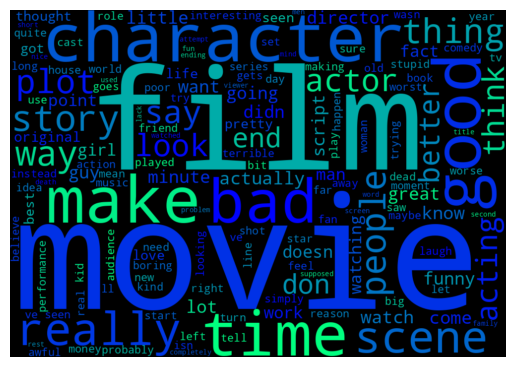

In [59]:
# Display the visualization
import matplotlib.pyplot as plt 

plt.imshow(image, interpolation='bilinear')
plt.axis('off')  # Hide the coordinate axes
plt.show()

## Vectorize or Embeddings

In [ ]:
# Frequency Based [ TF-IDF ]
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(cleaned_features)

X_tfidf[0].toarray()

array([[0., 0., 0., ..., 0., 0., 0.]], shape=(1, 103546))

In [ ]:
# Prediction Based [Word2Vec]

tokens = [doc.split() for doc in cleaned_features]

In [ ]:
# Training custom model using our data
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences= tokens,
    vector_size=250,
    min_count=2,
    sg = 1
)

In [68]:
# Downloading pre-trained Data
from gensim import downloader

twitter_200_model = downloader.load("glove-twitter-200")

[==================================================] 100.0% 758.5/758.5MB downloaded


In [79]:
import numpy as np

def vectorizer(tokens, model):
    vectors = [
        model[word] for word in tokens if word in model
    ]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)


embeddings = np.array([
    vectorizer(token, w2v_model.wv) for token in tokens
])

In [80]:
embeddings.shape

(49582, 250)

In [ ]:
# Contexualize text embeddings
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained("bert-base-uncased")

tokens = tokenizer(cleaned_features[:10], return_tensors='pt')

output = model(**tokens)

ImportError: 
BertModel requires the PyTorch library but it was not found in your environment. Check out the instructions on the
installation page: https://pytorch.org/get-started/locally/ and follow the ones that match your environment.
Please note that you may need to restart your runtime after installation.
